<a href="https://colab.research.google.com/github/sakshii951/DSPY_25-26/blob/main/Notebook15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Notebook 2: Exploratory Data Analysis (EDA)

##1. Import Required Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##2. Load Cleaned Dataset

In [ ]:
df = pd.read_csv('sample_data/cleaned_spam.csv')
df.head()

,label,message
0,0,hi how are you doing today
1,1,win money now click here
2,0,let s meet tomorrow at college
3,1,congratulations you have won a lottery claim now
4,0,can you send me the notes


##3. Dataset Overview

In [ ]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    20 non-null     int64 
 1   message  20 non-null     object
dtypes: int64(1), object(1)
memory usage: 452.0+ bytes


###Explanation:
* Understand dataset size and structure
* Verify cleaned data

#NON-GRAPHICAL ANALYSIS

##4. Analysis 1: Class Distribution
###Objective:

* To find number of spam and ham messages

In [ ]:
df['label'].value_counts()

,count
label,
0,10
1,10


##Observation:
* 0 → Ham messages are more frequent
* 1 → Spam messages are fewer
## Conclusion:
###Dataset is imbalanced (more ham than spam)

##5. Analysis 2: Message Length Statistics
###Objective:

* To compare message lengths between spam and ham

In [ ]:
df['length'] = df['message'].apply(len)
df.groupby('label')['length'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,10.0,27.1,3.900142,21.0,25.25,27.0,28.75,35.0
1,10.0,33.8,8.350649,24.0,27.50,32.0,39.00,48.0


##Observation:
* Spam messages generally have higher * average length
Ham messages are shorter
##Conclusion:
* Message length is an important
* distinguishing feature

##6. Analysis 3: Correlation Check
###Objective:

* To check relationship between features

In [ ]:
df[['label', 'length']].corr()

,label,length
label,1.000000,0.476401
length,0.476401,1.000000


###Observation:
* Positive correlation between spam and message length
### Conclusion:
* As message length increases, probability of spam increases

#GRAPHICAL ANALYSIS

##7. Graph 1: Count Plot (Univariate Analysis)
###Objective:

* To visualize distribution of spam vs ham

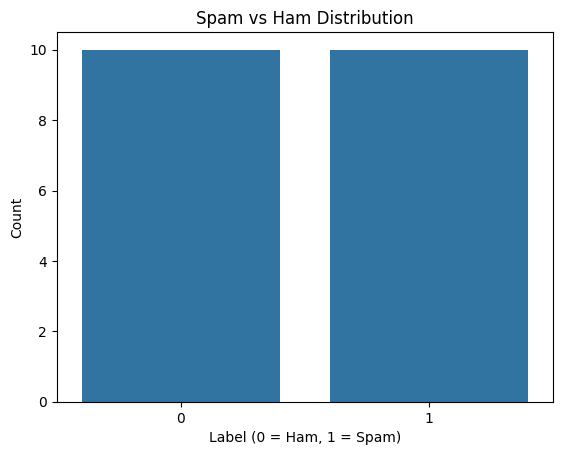

In [ ]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.xlabel("Label (0 = Ham, 1 = Spam)")
plt.ylabel("Count")
plt.show()

##Observation:
* Majority of messages are ham
## Conclusion:
* Clear class imbalance

## 8. Graph 2: Histogram of Message Length (Univariate)
###Objective:

* To observe distribution of message lengths

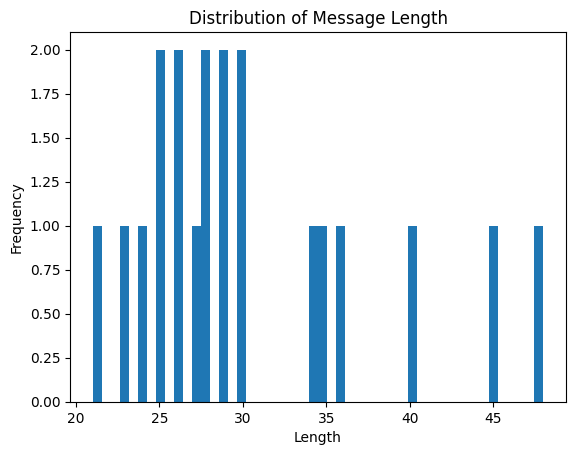

In [ ]:
plt.hist(df['length'], bins=50)
plt.title("Distribution of Message Length")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

###Observation:
* Most messages are short
* Few messages are very long
###Conclusion:
* Data is right-skewed

##9. Graph 3: Length vs Label (Multivariate Analysis)
###Objective:

* To compare message length for spam and ham

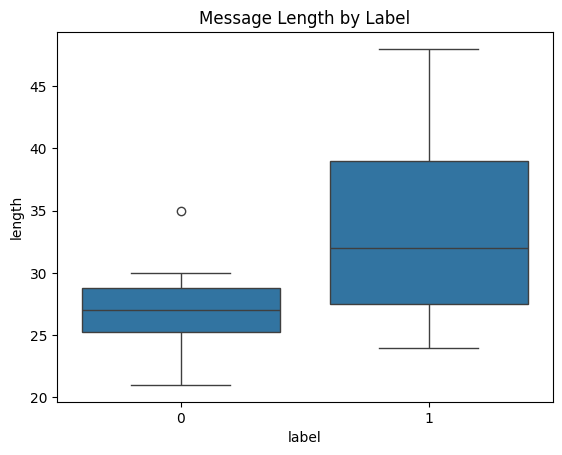

In [ ]:
sns.boxplot(x='label', y='length', data=df)
plt.title("Message Length by Label")
plt.show()

###Observation:
* Spam messages have higher median length
* Outliers present
### Conclusion:
* Strong separation between classes

##10. Graph 4: Histogram with Hue (Multivariate)
###Objective:

* To compare distributions of both classes

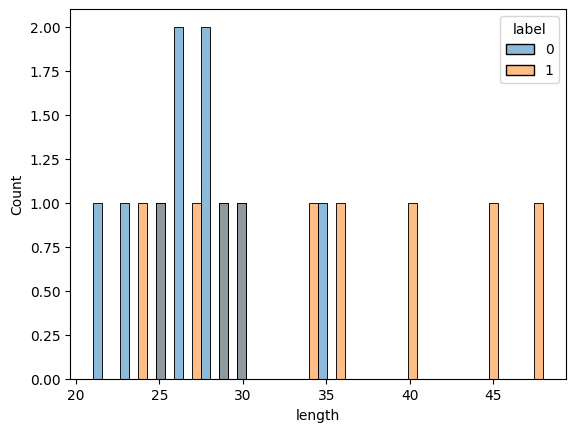

In [ ]:
sns.histplot(data=df, x='length', hue='label', bins=50)
plt.show()

###Observation:
* Spam messages dominate higher length values
###Conclusion:
* Length is a strong feature for classification